In [1]:
#01_exploration.ipynb
#
#by Joe Hahn
#jmh.datasciences@gmail.com
#3 August 2026
#
#explore & clean the tax-software sales data and do test/train split

In [2]:
#start time
import time as tm
clock_start = tm.time()

In [3]:
#import python libraries
import numpy as np
import pandas as pd
pd.set_option('display.max_columns', 500)    #tell pandas to display all columns
pd.set_option('display.width', 200)
pd.set_option('display.max_colwidth', 200)   #stop pandas truncating long text
import warnings
warnings.filterwarnings('ignore')
print('pandas = ', pd.__version__)
print('numpy  = ', np.__version__)

pandas =  3.0.5
numpy  =  2.4.6


In [4]:
#import plotting libraries
#use following line when in Jupyter
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(font_scale=1.3, font='DejaVu Sans', style='whitegrid')

In [5]:
#input parameters
data_file = 'project_data.csv'
target_col = 'successful_sell'
test_size = 0.25
rn_seed = 14
print('data_file  = ', data_file)
print('target_col = ', target_col)
print('test_size  = ', test_size)
print('rn_seed    = ', rn_seed)

data_file  =  project_data.csv
target_col =  successful_sell
test_size  =  0.25
rn_seed    =  14


In [6]:
#read csv file
raw = pd.read_csv(data_file)
print('raw.shape = ', raw.shape)
print('duplicate rows = ', raw.duplicated().sum())
raw.head()

raw.shape =  (41188, 23)
duplicate rows =  0


,age,b1,b2,c10,c3,c4,c8,dow,employment,i1,i2,i3,i4,i5,marriage-status,month,n2,n3,n4,n5,n6,school,successful_sell
0,34,yes,no,no,False,new,NaN,fri,management,-1.8,93.075,-47.1,1.405,5099.1,divorced,apr,2,530,999,0.001771,0,5 - a decent amount,no
1,28,yes,no,yes,False,new,NaN,thu,assistant,-1.8,92.893,-46.2,1.327,5099.1,divorced,may,1,750,999,-1.673152,0,5 - a lot,yes
2,55,no,no,no,unknown,new,NaN,tue,leisure,1.4,93.918,-42.7,4.962,5228.1,married,jul,3,600,999,0.927946,0,2 - a little bit,no
3,47,yes,no,no,False,new,NaN,mon,assistant,-0.1,93.200,-42.0,4.191,5195.8,married,nov,1,860,999,0.203013,0,5 - a lot,no
4,49,no,no,no,unknown,new,NaN,tue,assistant,1.4,93.918,-42.7,4.961,5228.1,married,jul,6,620,999,0.990804,0,5 - a lot,no


In [7]:
#column types, distinct values, and missing counts
df = raw
overview = pd.DataFrame({
    'dtype': df.dtypes.astype(str),
    'N_unique': df.nunique(dropna=False),
    'N_missing': df.isna().sum(),
    'pct_missing': (df.isna().mean()*100).round(1),
    'example': [df[c].dropna().iloc[0] for c in df.columns],
})
print('columns with missing values = ', list(overview[overview.N_missing > 0].index))
overview

columns with missing values =  ['b2', 'c8', 'marriage-status', 'school']


,dtype,N_unique,N_missing,pct_missing,example
age,int64,78,0,0.0,34
b1,str,3,0,0.0,yes
b2,str,3,990,2.4,no
c10,str,2,0,0.0,no
c3,str,3,0,0.0,False
c4,str,2,0,0.0,new
c8,str,3,35563,86.3,no
dow,str,5,0,0.0,fri
employment,str,12,0,0.0,management
i1,float64,10,0,0.0,-1.8


In [8]:
#the target is complete, so encode it as 1/0
df = raw
y = (df[target_col] == 'yes').astype(int)
print(df[target_col].value_counts(dropna=False))
print()
print('missing values in the target = ', df[target_col].isna().sum())
print('buyers                       = ', format(y.sum(), ','), '  (', round(y.mean()*100, 2), '%)')
print('non-buyers                   = ', format((1 - y).sum(), ','))
print('imbalance                    = ', round((1 - y.mean())/y.mean(), 1), 'to 1')

successful_sell
no     36548
yes     4640
Name: count, dtype: int64

missing values in the target =  0
buyers                       =  4,640   ( 11.27 %)
non-buyers                   =  36,548
imbalance                    =  7.9 to 1


In [9]:
#categorical levels...note b1 has a '-1' level, c3 has only 3 'True' rows, and two
#school levels both start with 5
df = raw
for col in df.select_dtypes('object').columns:
    print('--- ' + col + '   (' + str(df[col].nunique(dropna=False)) + ' levels) ---')
    print(df[col].value_counts(dropna=False).head(12).to_string())
    print()

--- b1   (3 levels) ---
b1
yes    21576
no     18622
-1       990

--- b2   (3 levels) ---
b2
no     33950
yes     6248
NaN      990

--- c10   (2 levels) ---
c10
no     36548
yes     4640

--- c3   (3 levels) ---
c3
False      32588
unknown     8597
True           3

--- c4   (2 levels) ---
c4
new    26144
old    15044

--- c8   (3 levels) ---
c8
NaN    35563
no      4252
yes     1373

--- dow   (5 levels) ---
dow
thu    8623
mon    8514
wed    8134
tue    8090
fri    7827

--- employment   (12 levels) ---
employment
assistant           10422
laborer              9254
engineer             6743
customer service     3969
management           2924
leisure              1720
hobbyist             1456
self-employed        1421
cleaner              1060
none                 1014
student               875
unknown               330

--- marriage-status   (4 levels) ---
marriage-status
married     24928
single      11568
divorced     4612
NaN            80

--- month   (10 levels) ---
month
may

In [10]:
#The ai coding assistant recognized this as the public UCI Bank Marketing dataset
#(Moro, Cortez & Rita 2014) from the dataframe's shape and the fields that were left
#un-obfuscated, then inferred the remaining names by inspecting their distributions.
#the counts all match the public data exactly, with two changes: the original 'duration'
#column was removed, and c10 was added.
glossary = pd.DataFrame([
    ('age', 'age', 'customer age in years',
     'arrived named, range 17-98 is plausible'),
    ('employment', 'employment', 'occupation',
     "arrived named; 'leisure' has mean age 62, so retirees"),
    ('marriage-status', 'marriage_status', 'marital status',
     'arrived named, hyphen swapped for an underscore so df.column works'),
    ('school', 'school', 'education attainment',
     "arrived named, but two levels are both numbered 5, see section 2"),
    ('dow', 'dow', 'weekday of contact',
     'arrived named, mon-fri only, no weekends'),
    ('month', 'month', 'month of contact',
     'arrived named, january and february never appear'),
    ('b1', 'has_housing_loan*', 'holds a housing loan',
     "yes/no plus a '-1' level of 990 rows that lines up with b2's 990 nulls"),
    ('b2', 'has_personal_loan*', 'holds a personal loan',
     "yes/no, its nulls are the same customers as b1's '-1'"),
    ('c3', 'credit_in_default*', 'in credit default',
     'False / unknown / True, with only 3 True rows'),
    ('c4', 'contact_channel*', 'how the customer was reached',
     'two levels, 3x difference in sell rate, but half of that is the economy'),
    ('c8', 'prior_campaign_outcome*', 'result of the previous campaign',
     'yes/no, null for exactly the 35,563 customers with n6 == 0'),
    ('c10', 'unknown_c10', 'could not decode',
     "two levels whose counts exactly match the target's, see section 1"),
    ('n2', 'contacts_this_campaign*', 'calls made during this campaign',
     '1 to 56, and the sell rate falls steadily as it rises'),
    ('n3', 'unknown_n3', 'could not decode',
     '50 evenly spaced integers in [500, 990], see section 1'),
    ('n4', 'days_since_prior_contact*', 'days since last contact, 999 = never',
     '96% of rows are exactly 999 and those rows behave completely differently'),
    ('n5', 'unknown_n5', 'could not decode',
     '41,188 unique floats, mean 0.000, sd 0.997, see section 1'),
    ('n6', 'prior_contact_count*', 'contacts before this campaign',
     '0 to 7, sell rate rises sharply with it'),
    ('i1', 'emp_variation_rate*', 'employment variation rate',
     'constant within each i5 period, a macroeconomic figure'),
    ('i2', 'consumer_price_index*', 'consumer price index',
     'constant within period, values 92.2-94.8'),
    ('i3', 'consumer_confidence_index*', 'consumer confidence index',
     'constant within period, all negative'),
    ('i4', 'euribor_3m*', '3-month interbank interest rate',
     '316 values from 5.05 down to 0.63, it moves almost daily'),
    ('i5', 'n_employed*', 'number employed, thousands',
     'exactly 11 values, our index of which period a customer belongs to'),
    ('successful_sell', 'target', 'did they buy?',
     'arrived named, this is what we predict, 11.27% yes'),
], columns=['original', 'our_name', 'meaning', 'evidence'])
print('glossary.shape = ', glossary.shape)
glossary

glossary.shape =  (23, 4)


,original,our_name,meaning,evidence
0,age,age,customer age in years,"arrived named, range 17-98 is plausible"
1,employment,employment,occupation,"arrived named; 'leisure' has mean age 62, so retirees"
2,marriage-status,marriage_status,marital status,"arrived named, hyphen swapped for an underscore so df.column works"
3,school,school,education attainment,"arrived named, but two levels are both numbered 5, see section 2"
4,dow,dow,weekday of contact,"arrived named, mon-fri only, no weekends"
5,month,month,month of contact,"arrived named, january and february never appear"
6,b1,has_housing_loan*,holds a housing loan,yes/no plus a '-1' level of 990 rows that lines up with b2's 990 nulls
7,b2,has_personal_loan*,holds a personal loan,"yes/no, its nulls are the same customers as b1's '-1'"
8,c3,credit_in_default*,in credit default,"False / unknown / True, with only 3 True rows"
9,c4,contact_channel*,how the customer was reached,"two levels, 3x difference in sell rate, but half of that is the economy"


## 1. columns deserving close inspection

In [11]:
#c10 LEAKS THE TARGET: it is a verbatim copy of successful_sell, so we drop it.
#found by scoring every low-cardinality column on the accuracy it would reach by
#mapping its values straight onto the outcome. worth running against any new dataset.
df = raw
rows = []
for col in df.columns.drop(target_col):
    if df[col].nunique(dropna=False) > 50:
        continue    #a near-unique column would trivially predict anything
    N_hits = pd.crosstab(df[col].fillna('<null>'), df[target_col]).max(axis=1).sum()
    rows.append({'column': col, 'N_levels': df[col].nunique(dropna=False),
                 'best_accuracy': N_hits*1.0/len(df)})
leak_scan = pd.DataFrame(rows).sort_values('best_accuracy', ascending=False).reset_index(drop=True)
leak_scan['verdict'] = np.where(leak_scan.best_accuracy >= 0.999, 'LEAK',
                        np.where(leak_scan.best_accuracy > 0.95, 'suspicious', 'ok'))
print(leak_scan.head(8).to_string(index=False))
print()
print('c10 scores a perfect 1.000, everything else sits near 0.887, which is just')
print('the accuracy of guessing no for everybody. c10 is the target under another name:')
print()
print(pd.crosstab(raw.c10, raw[target_col], margins=True))

column  N_levels  best_accuracy verdict
   c10         2       1.000000    LEAK
    n4        27       0.898053      ok
    c8         3       0.897422      ok
    i2        26       0.891158      ok
    i3        26       0.891158      ok
    i5        11       0.890381      ok
    n6         8       0.888681      ok
    i1        10       0.888244      ok

c10 scores a perfect 1.000, everything else sits near 0.887, which is just
the accuracy of guessing no for everybody. c10 is the target under another name:

successful_sell     no   yes    All
c10                                
no               36548     0  36548
yes                  0  4640   4640
All              36548  4640  41188


n3:  50  distinct values from  500  to  990 , spacing =  [10]
n5:  41,188  distinct values, mean =  -0.0001 , sd =  0.997

column     compared_with  distribution_test_p  buyers_vs_nonbuyers_p
    n3 Uniform(500, 990)         7.541869e-16               0.813044
    n5      Normal(0, 1)         9.605650e-01               0.380435


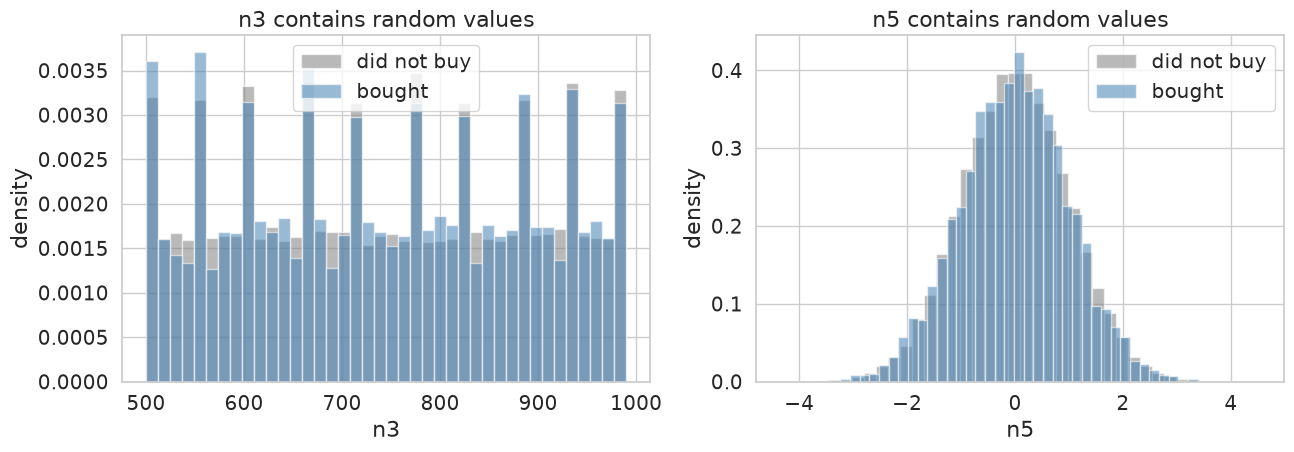

In [12]:
#n3 and n5 APPEAR TO BE RANDOM NUMBERS, so they predict nothing. we keep them anyway since
#a known column sets a floor for any feature importance chart
from scipy import stats
df = raw
print('n3: ', df.n3.nunique(), ' distinct values from ', df.n3.min(), ' to ', df.n3.max(),
      ', spacing = ', np.unique(np.diff(np.sort(df.n3.unique()))))
print('n5: ', format(df.n5.nunique(), ','), ' distinct values, mean = ',
      round(df.n5.mean(), 4), ', sd = ', round(df.n5.std(), 4))
print()
noise_tests = pd.DataFrame([
    {'column': 'n3', 'compared_with': 'Uniform(500, 990)',
     'distribution_test_p': stats.kstest(df.n3, 'uniform', args=(500, 490)).pvalue,
     'buyers_vs_nonbuyers_p': stats.ttest_ind(df.n3[y == 1], df.n3[y == 0]).pvalue},
    {'column': 'n5', 'compared_with': 'Normal(0, 1)',
     'distribution_test_p': stats.kstest(df.n5, 'norm').pvalue,
     'buyers_vs_nonbuyers_p': stats.ttest_ind(df.n5[y == 1], df.n5[y == 0]).pvalue},
])
print(noise_tests.to_string(index=False))

sns.set(font_scale=1.3, font='DejaVu Sans', style='whitegrid')
fig, ax = plt.subplots(1, 2, figsize=(15, 4.5))
for jdx, col in enumerate(['n3', 'n5']):
    xp = df[col][y == 0]
    p = ax[jdx].hist(xp, bins=40, density=True, alpha=0.55, color='grey', label='did not buy')
    xp = df[col][y == 1]
    p = ax[jdx].hist(xp, bins=40, density=True, alpha=0.55, color='steelblue', label='bought')
    p = ax[jdx].set_title(col + ' contains random values')
    p = ax[jdx].set_xlabel(col)
    p = ax[jdx].set_ylabel('density')
    p = ax[jdx].legend()

## 2. data quality: each problem, and their fix

In [13]:
#NO DUPLICATE ROWS and no obvious impossible values
df = raw
print('duplicate rows       = ', df.duplicated().sum())
print('ages outside 17-100  = ', ((df.age < 17) | (df.age > 100)).sum())
print('negative call counts = ', (df.n2 < 0).sum())

duplicate rows       =  0
ages outside 17-100  =  0
negative call counts =  0


In [14]:
#DROP c10 AND THE TARGET, then rename the obfuscated fields. 
rename_map = {
    'marriage-status': 'marriage_status',        #cosmetic only, a hyphen breaks df.column access
    'n3': 'unknown_n3', 'n5': 'unknown_n5',      #could not decode these two
    'b1': 'has_housing_loan*', 'b2': 'has_personal_loan*',
    'c3': 'credit_in_default*', 'c4': 'contact_channel*',
    'c8': 'prior_campaign_outcome*', 'n2': 'contacts_this_campaign*',
    'n4': 'days_since_prior_contact*', 'n6': 'prior_contact_count*',
    'i1': 'emp_variation_rate*', 'i2': 'consumer_price_index*',
    'i3': 'consumer_confidence_index*', 'i4': 'euribor_3m*',
    'i5': 'n_employed*',
}
df = raw.drop(columns=['c10', target_col]).rename(columns=rename_map)
clean = df
print('columns before = ', raw.shape[1])
print('columns after  = ', clean.shape[1], '  (dropped c10 and the target)')
print('renamed        = ', len(rename_map), ' obfuscated fields')
print('kept as-is     = ', [c for c in clean.columns if not c.endswith('*')])
clean.head()

columns before =  23
columns after  =  21   (dropped c10 and the target)
renamed        =  16  obfuscated fields
kept as-is     =  ['age', 'dow', 'employment', 'marriage_status', 'month', 'unknown_n3', 'unknown_n5', 'school']


,age,has_housing_loan*,has_personal_loan*,credit_in_default*,contact_channel*,prior_campaign_outcome*,dow,employment,emp_variation_rate*,consumer_price_index*,consumer_confidence_index*,euribor_3m*,n_employed*,marriage_status,month,contacts_this_campaign*,unknown_n3,days_since_prior_contact*,unknown_n5,prior_contact_count*,school
0,34,yes,no,False,new,NaN,fri,management,-1.8,93.075,-47.1,1.405,5099.1,divorced,apr,2,530,999,0.001771,0,5 - a decent amount
1,28,yes,no,False,new,NaN,thu,assistant,-1.8,92.893,-46.2,1.327,5099.1,divorced,may,1,750,999,-1.673152,0,5 - a lot
2,55,no,no,unknown,new,NaN,tue,leisure,1.4,93.918,-42.7,4.962,5228.1,married,jul,3,600,999,0.927946,0,2 - a little bit
3,47,yes,no,False,new,NaN,mon,assistant,-0.1,93.200,-42.0,4.191,5195.8,married,nov,1,860,999,0.203013,0,5 - a lot
4,49,no,no,unknown,new,NaN,tue,assistant,1.4,93.918,-42.7,4.961,5228.1,married,jul,6,620,999,0.990804,0,5 - a lot


In [15]:
#990 CUSTOMERS (2.4%) ARE MISSING BOTH HOUSING & PERSONAL LOAN FIELDS, the same 990 in
#each, so this is a data-collection gap to fix at source rather than a meaningful 'no'
df = raw
print("b1 == '-1'                 = ", (df.b1 == '-1').sum(),
      '  (', round((df.b1 == '-1').mean()*100, 1), '% of records)')
print('b2 is null                 = ', df.b2.isna().sum())
print('both, on the same customer = ', ((df.b1 == '-1') & df.b2.isna()).sum())

b1 == '-1'                 =  990   ( 2.4 % of records)
b2 is null                 =  990
both, on the same customer =  990


In [16]:
#ONLY has_housing_loan* NEEDS AN INTERVENTION: it writes missing as the string '-1',
#while has_personal_loan* already uses a real null. normalising the two to match means
#the single -1 encoding at the end of this section covers both.
df = clean
print('before:')
print(df['has_housing_loan*'].value_counts(dropna=False).to_string())
df['has_housing_loan*'] = df['has_housing_loan*'].replace('-1', np.nan)
clean = df
print()
print('after:')
print(clean['has_housing_loan*'].value_counts(dropna=False).to_string())
print()
print('has_personal_loan* is untouched, already null on those same 990 customers:')
print(clean['has_personal_loan*'].value_counts(dropna=False).to_string())

before:
has_housing_loan*
yes    21576
no     18622
-1       990

after:
has_housing_loan*
yes    21576
no     18622
NaN      990

has_personal_loan* is untouched, already null on those same 990 customers:
has_personal_loan*
no     33950
yes     6248
NaN      990


In [17]:
#credit_in_default* and employment write missing as the string 'unknown'. normalise
#to nulls, but keep them: an undisclosed credit status can be predictive
df = raw
print('sell rate by credit_in_default*, as delivered:')
print(pd.DataFrame({'y': y}).groupby(df.c3).y.agg(['size', 'mean']).round(3).to_string())
df = clean
unknown_counts = (df == 'unknown').sum()
unknown_counts = unknown_counts[unknown_counts > 0]
df = df.replace('unknown', np.nan)
clean = df
print()
print('converted to nulls = ', dict(unknown_counts))
assert not (clean == 'unknown').any().any()

sell rate by credit_in_default*, as delivered:
          size   mean
c3                   
False    32588  0.129
True         3  0.000
unknown   8597  0.052

converted to nulls =  {'credit_in_default*': np.int64(8597), 'employment': np.int64(330)}


In [18]:
#credit_in_default* arrives as 'True'/'False' strings, recode to yes/no
df = clean
df['credit_in_default*'] = df['credit_in_default*'].map({'True': 'yes', 'False': 'no'})
clean = df
print(clean['credit_in_default*'].value_counts(dropna=False).to_string())
assert set(clean['credit_in_default*'].dropna().unique()) <= {'yes', 'no'}

credit_in_default*
no     32588
NaN     8597
yes        3


In [19]:
#96% OF days_since_prior_contact* IS THE SENTINAL 999, which reads as a real duration
#and drags the mean to 962 for a column whose genuine values stop at 27 days
df = raw
print('rows where n4 == 999 = ', (df.n4 == 999).sum(),
      '  (', round((df.n4 == 999).mean()*100, 1), '% of records)')
print()
print('n4 as delivered:')
print(df.n4.describe().round(1).to_string())
print()
print('n4 with the 999s filtered out:')
print(df.n4[df.n4 != 999].describe().round(1).to_string())
print()
print('the genuine values top out at 27 days, but the 999s drag the mean to 962')

rows where n4 == 999 =  39673   ( 96.3 % of records)

n4 as delivered:
count    41188.0
mean       962.5
std        186.9
min          0.0
25%        999.0
50%        999.0
75%        999.0
max        999.0

n4 with the 999s filtered out:
count    1515.0
mean        6.0
std         3.8
min         0.0
25%         3.0
50%         6.0
75%         7.0
max        27.0

the genuine values top out at 27 days, but the 999s drag the mean to 962


In [20]:
#and the two groups sell at completely different rates, so the sentinel is signal
df = raw
idx = (df.n4 == 999)
print('never contacted before (n4 == 999) = ', round(y[idx].mean()*100, 1), '% bought')
print('contacted before                   = ', round(y[~idx].mean()*100, 1), '% bought')
print('ratio                              = ', round(y[~idx].mean()/y[idx].mean(), 1), 'x')
print()
print('a strong signal, but only if we encode it as a flag rather than a fake duration')

never contacted before (n4 == 999) =  9.3 % bought
contacted before                   =  63.8 % bought
ratio                              =  6.9 x

a strong signal, but only if we encode it as a flag rather than a fake duration


In [21]:
#CLEAR THE 999 SENTINAL AND INSTEAD FLAG IT WITH NaN, and
#create new never_contacted_before feature 
df = clean
never_contacted = (df['days_since_prior_contact*'] == 999)
print('before: min = ', df['days_since_prior_contact*'].min(),
      '  max = ', df['days_since_prior_contact*'].max(),
      '  mean = ', round(df['days_since_prior_contact*'].mean()))
df.loc[never_contacted, 'days_since_prior_contact*'] = np.nan
df['never_contacted_before'] = never_contacted.astype(int)
clean = df
print('after:  min = ', clean['days_since_prior_contact*'].min(),
      '  max = ', clean['days_since_prior_contact*'].max(),
      '  mean = ', round(clean['days_since_prior_contact*'].mean(), 1),
      '  nulls = ', format(clean['days_since_prior_contact*'].isna().sum(), ','))
print()
print('new feature never_contacted_before vs the original 999 sentinel:')
print(pd.crosstab(clean.never_contacted_before, raw.n4 == 999))

before: min =  0   max =  999   mean =  962
after:  min =  0.0   max =  27.0   mean =  6.0   nulls =  39,673

new feature never_contacted_before vs the original 999 sentinel:
n4                      False  True 
never_contacted_before              
0                        1515      0
1                           0  39673


In [22]:
#TWO DIFFERENT education LEVELS ARE BOTH NUMBERED 5, so taking the leading number would
#silently merge 42% of customers into one bucket. no repair needed, we just never treat
#this column as a number...it stays an unordered category and the model sorts it out
df = raw
edu_audit = pd.DataFrame({'label': df.school, 'y': y}).groupby('label', dropna=False).agg(
    N_customers=('y', 'size'), sell_rate=('y', 'mean')).sort_values('sell_rate')
N_merged = df.school.isin(['5 - a lot', '5 - a decent amount']).sum()
print('distinct labels                         = ', df.school.nunique())
print('distinct values after taking the prefix = ', df.school.str.split(' - ').str[0].nunique())
print('customers merged into one bucket        = ', format(N_merged, ','),
      ' (', round(N_merged*100.0/len(df)), '%)')
print()
print('and note the sell rate falls then rises, so it is not a usable ordinal either:')
edu_audit.round(3)

distinct labels                         =  7
distinct values after taking the prefix =  6
customers merged into one bucket        =  17,411  ( 42 %)

and note the sell rate falls then rises, so it is not a usable ordinal either:


,N_customers,sell_rate
label,,
3 - a bit more,6045,0.078
2 - a little bit,2292,0.082
1 - almost none,4176,0.102
4 - average amount,9515,0.108
5 - a decent amount,5243,0.113
5 - a lot,12168,0.137
NaN,1731,0.145
0 - none,18,0.222


In [23]:
#ENCODE EVERY NULL AS -1, the convention the file already used for b1.
#one-hot encoding gives '-1' its own dummy, which suits a tree and a logistic
#regression equally. the exception is days_since_prior_contact*, numeric, where a
#linear model would read -1 as a duration...notebook 2 median-imputes that one
#column and leans on the never_contacted_before flag instead.
df = clean
missing_before = df.isna().sum()
missing_before = missing_before[missing_before > 0]
cat_cols = df.select_dtypes(exclude='number').columns
num_cols = df.select_dtypes(include='number').columns
df[cat_cols] = df[cat_cols].fillna('-1')
df[num_cols] = df[num_cols].fillna(-1)
clean = df
print('nulls before -1 encoding:')
print(missing_before.to_string())
print()
print('nulls after  = ', clean.isna().sum().sum())
print()
print('the two biggest, prior_campaign_outcome* and days_since_prior_contact*,')
print('mean "this never happened" rather than "we failed to record it". -1 says exactly that.')
clean.sample(5, random_state=rn_seed)

nulls before -1 encoding:
has_housing_loan*              990
has_personal_loan*             990
credit_in_default*            8597
prior_campaign_outcome*      35563
employment                     330
marriage_status                 80
days_since_prior_contact*    39673
school                        1731

nulls after  =  0

the two biggest, prior_campaign_outcome* and days_since_prior_contact*,
mean "this never happened" rather than "we failed to record it". -1 says exactly that.


,age,has_housing_loan*,has_personal_loan*,credit_in_default*,contact_channel*,prior_campaign_outcome*,dow,employment,emp_variation_rate*,consumer_price_index*,consumer_confidence_index*,euribor_3m*,n_employed*,marriage_status,month,contacts_this_campaign*,unknown_n3,days_since_prior_contact*,unknown_n5,prior_contact_count*,school,never_contacted_before
16295,56,no,no,no,old,-1,fri,assistant,1.4,94.465,-41.8,4.959,5228.1,married,jun,2,730,-1.0,-1.482944,0,4 - average amount,1
10416,57,yes,no,no,new,-1,tue,laborer,-1.8,92.893,-46.2,1.344,5099.1,married,may,1,860,-1.0,0.336592,0,3 - a bit more,1
2888,56,yes,no,no,new,-1,wed,hobbyist,-1.8,93.075,-47.1,1.415,5099.1,married,apr,12,630,-1.0,1.246612,0,3 - a bit more,1
29163,26,yes,no,no,old,-1,fri,laborer,1.1,93.994,-36.4,4.864,5191.0,single,may,1,640,-1.0,0.808844,0,3 - a bit more,1
18945,56,no,no,no,new,yes,tue,leisure,-1.7,94.055,-39.8,0.761,4991.6,married,jun,1,720,3.0,-0.430925,1,4 - average amount,0


## 3. who buys?

In [24]:
#11.27% of contacted customers bought, about one in nine
print('sell rate = ', round(y.mean()*100, 2), '%')
print()
print('a model that says "no" to everyone would be ', round((1 - y.mean())*100, 1), '% accurate')
print('and would sell nothing. accuracy is the wrong measure for this problem,')
print('so we use roc_auc and precision/recall instead.')

sell rate =  11.27 %

a model that says "no" to everyone would be  88.7 % accurate
and would sell nothing. accuracy is the wrong measure for this problem,
so we use roc_auc and precision/recall instead.


,rate,n
level,,
(no prior campaign),0.088,35563
no,0.142,4252
yes,0.651,1373


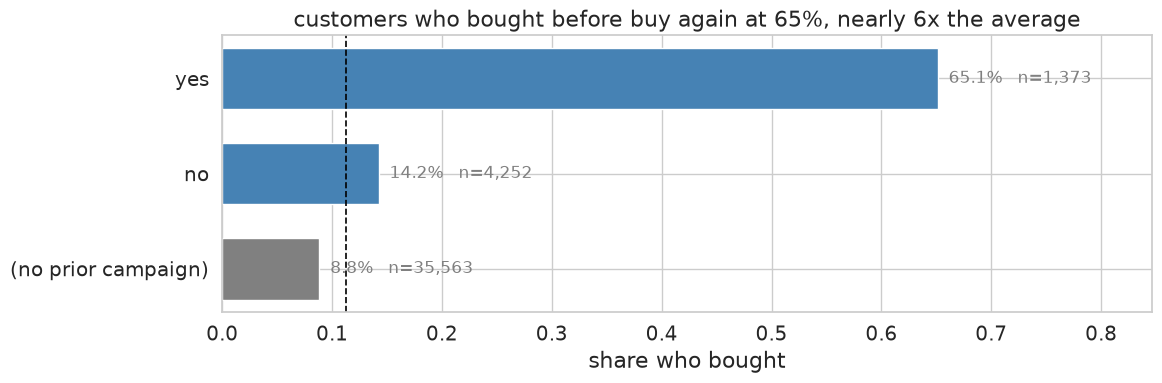

In [25]:
#plot sell rate by prior_campaign_outcome*...the strongest single signal we have.
df = clean
tab = pd.DataFrame({'level': df['prior_campaign_outcome*'].replace(
                        {'-1': '(no prior campaign)'}),
                    'y': y}).groupby('level', observed=True).agg(
    rate=('y', 'mean'), n=('y', 'size')).sort_values('rate')
sns.set(font_scale=1.3, font='DejaVu Sans', style='whitegrid')
fig, ax = plt.subplots(1, 1, figsize=(12, 3.6))
colors = ['steelblue' if r > y.mean() else 'grey' for r in tab.rate]
p = ax.barh(tab.index.astype(str), tab.rate, color=colors, height=0.65)
for jdx in range(len(tab)):
    p = ax.text(tab.rate.iloc[jdx] + 0.01, jdx,
                str(round(tab.rate.iloc[jdx]*100, 1)) + '%   n=' + format(tab.n.iloc[jdx], ','),
                va='center', fontsize=12, color='grey')
p = ax.axvline(y.mean(), color='black', linestyle='--', linewidth=1.2)
p = ax.set_xlim(0, tab.rate.max()*1.3)
p = ax.set_title('customers who bought before buy again at 65%, nearly 6x the average')
p = ax.set_xlabel('share who bought')
tab.round(3)

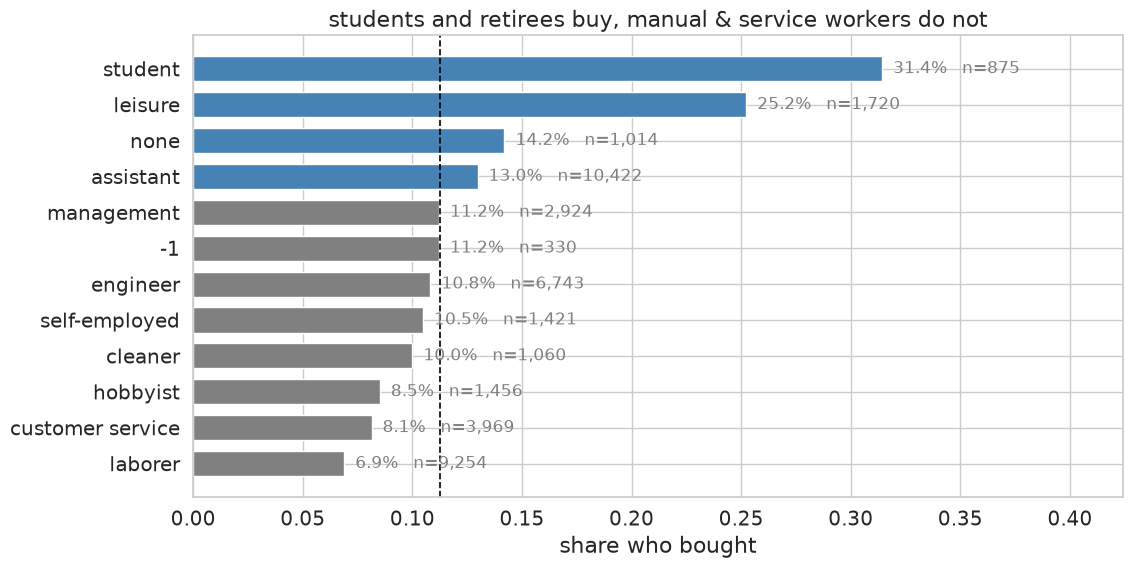

In [26]:
#plot sell rate by occupation
df = clean
tab = pd.DataFrame({'level': df.employment, 'y': y}).groupby(
    'level', observed=True).agg(rate=('y', 'mean'), n=('y', 'size')).sort_values('rate')
sns.set(font_scale=1.3, font='DejaVu Sans', style='whitegrid')
fig, ax = plt.subplots(1, 1, figsize=(12, 6))
colors = ['steelblue' if r > y.mean() else 'grey' for r in tab.rate]
p = ax.barh(tab.index.astype(str), tab.rate, color=colors, height=0.7)
for jdx in range(len(tab)):
    p = ax.text(tab.rate.iloc[jdx] + 0.005, jdx,
                str(round(tab.rate.iloc[jdx]*100, 1)) + '%   n=' + format(tab.n.iloc[jdx], ','),
                va='center', fontsize=12, color='grey')
p = ax.axvline(y.mean(), color='black', linestyle='--', linewidth=1.2)
p = ax.set_xlim(0, tab.rate.max()*1.35)
p = ax.set_title('students and retirees buy, manual & service workers do not')
p = ax.set_xlabel('share who bought')

In [27]:
#'leisure' PROBABLY = RETIRES, check mean age by job
df = clean
df.groupby('employment').age.agg(['mean', 'size']).sort_values('mean', ascending=False).round(1)

,mean,size
employment,,
leisure,62.0,1720
-1,45.6,330
cleaner,45.5,1060
management,42.4,2924
hobbyist,41.7,1456
self-employed,39.9,1421
none,39.7,1014
laborer,39.6,9254
engineer,38.5,6743


inside the biggest economic state (5228.1):
       size   mean
chan              
new   10724  0.059
old    5510  0.042


,rate,n
level,,
old,0.052,15044
new,0.147,26144


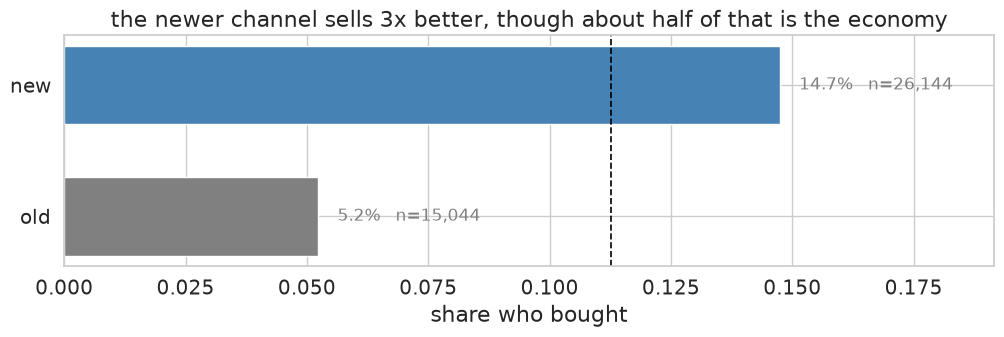

In [28]:
#plot sell rate by contact_channel*...but check it the same way we checked month, since
#the newer channel was used more in the low-rate periods (mean euribor 3.1 vs 4.5).
#holding the economy fixed the gap halves, so about half the headline 3x is the economy
df = clean
tab = pd.DataFrame({'level': df['contact_channel*'], 'y': y}).groupby(
    'level', observed=True).agg(rate=('y', 'mean'), n=('y', 'size')).sort_values('rate')
sns.set(font_scale=1.3, font='DejaVu Sans', style='whitegrid')
fig, ax = plt.subplots(1, 1, figsize=(12, 3))
colors = ['steelblue' if r > y.mean() else 'grey' for r in tab.rate]
p = ax.barh(tab.index.astype(str), tab.rate, color=colors, height=0.6)
for jdx in range(len(tab)):
    p = ax.text(tab.rate.iloc[jdx] + 0.004, jdx,
                str(round(tab.rate.iloc[jdx]*100, 1)) + '%   n=' + format(tab.n.iloc[jdx], ','),
                va='center', fontsize=12, color='grey')
p = ax.axvline(y.mean(), color='black', linestyle='--', linewidth=1.2)
p = ax.set_xlim(0, tab.rate.max()*1.3)
p = ax.set_title("the newer channel sells 3x better, though about half of that is the economy")
p = ax.set_xlabel('share who bought')
biggest = df['n_employed*'].value_counts().index[0]
sub = pd.DataFrame({'chan': df['contact_channel*'], 'y': y})[df['n_employed*'] == biggest]
print('inside the biggest economic state (', biggest, '):', sep='')
print(sub.groupby('chan').y.agg(['size', 'mean']).round(3).to_string())
tab.round(3)

In [29]:
#bin age and compute sell rate per bin
df = clean
age_bins = [16, 25, 30, 40, 50, 60, 70, 100]
age_tab = pd.DataFrame({'bin': pd.cut(df.age, age_bins), 'y': y}).groupby(
    'bin', observed=True).agg(N_customers=('y', 'size'), sell_rate=('y', 'mean'))
age_tab.round(3)

,N_customers,sell_rate
bin,,
"(16, 25]",1666,0.209
"(25, 30]",5717,0.136
"(30, 40]",16385,0.097
"(40, 50]",10240,0.082
"(50, 60]",6270,0.107
"(60, 70]",488,0.434
"(70, 100]",422,0.479


over-70s buy at ~6x the rate of 40-50 year olds. a straight-line model cannot fit this,
so notebook 2 gives the logistic regression a spline basis for age.


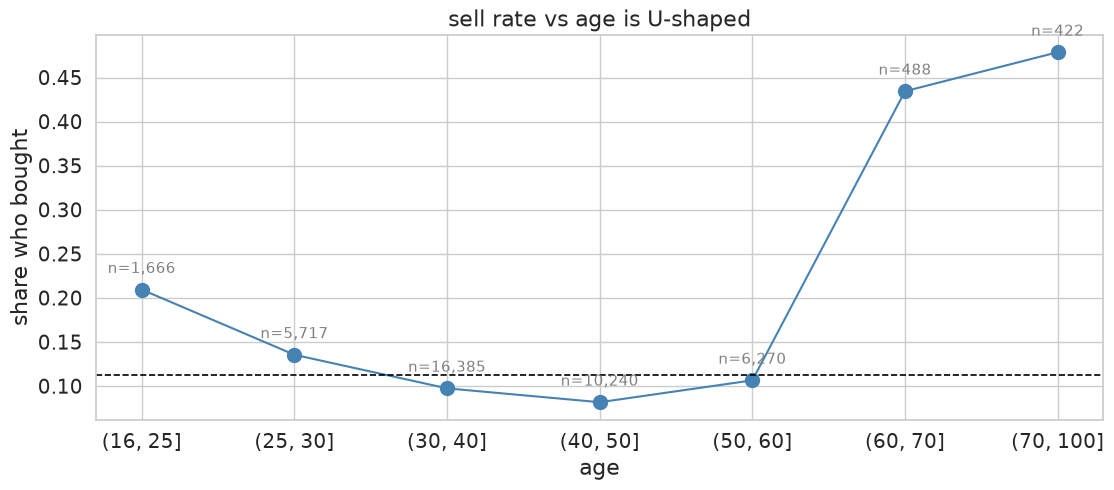

In [30]:
#plot sell rate vs age...it is U-shaped, the young and the old buy but the middle-aged do not
df = age_tab
sns.set(font_scale=1.3, font='DejaVu Sans', style='whitegrid')
fig, ax = plt.subplots(1, 1, figsize=(13, 5))
xp = range(len(df))
yp = df.sell_rate
p = ax.plot(xp, yp, linestyle='-', marker='o', markersize=10, color='steelblue')
p = ax.axhline(y.mean(), color='black', linestyle='--', linewidth=1.2)
for jdx in range(len(df)):
    p = ax.annotate('n=' + format(df.N_customers.iloc[jdx], ','), (jdx, df.sell_rate.iloc[jdx]),
                    textcoords='offset points', xytext=(0, 12), ha='center', fontsize=11, color='grey')
p = ax.set_xticks(list(xp))
p = ax.set_xticklabels([str(i) for i in df.index])
p = ax.set_title('sell rate vs age is U-shaped')
p = ax.set_xlabel('age')
p = ax.set_ylabel('share who bought')
print('over-70s buy at ~6x the rate of 40-50 year olds. a straight-line model cannot fit this,')
print('so notebook 2 gives the logistic regression a spline basis for age.')

In [31]:
#bin the number of calls made to the same person, and flag repeat contacts as a feature
df = clean
df['is_repeat_contact'] = (df['contacts_this_campaign*'] > 1).astype(int)
clean = df
campaign_bins = [0, 1, 2, 3, 5, 10, 60]
campaign_tab = pd.DataFrame({'bin': pd.cut(df['contacts_this_campaign*'], campaign_bins), 'y': y}).groupby(
    'bin', observed=True).agg(N_customers=('y', 'size'), sell_rate=('y', 'mean'))
print('new feature is_repeat_contact vs contacts_this_campaign*:')
print(clean.groupby('is_repeat_contact')['contacts_this_campaign*'].agg(['min', 'max', 'size']))
print()
campaign_tab.round(3)

new feature is_repeat_contact vs contacts_this_campaign*:
                   min  max   size
is_repeat_contact                 
0                    1    1  17642
1                    2   56  23546



,N_customers,sell_rate
bin,,
"(0, 1]",17642,0.130
"(1, 2]",10570,0.115
"(2, 3]",5341,0.107
"(3, 5]",4250,0.087
"(5, 10]",2516,0.063
"(10, 60]",869,0.031


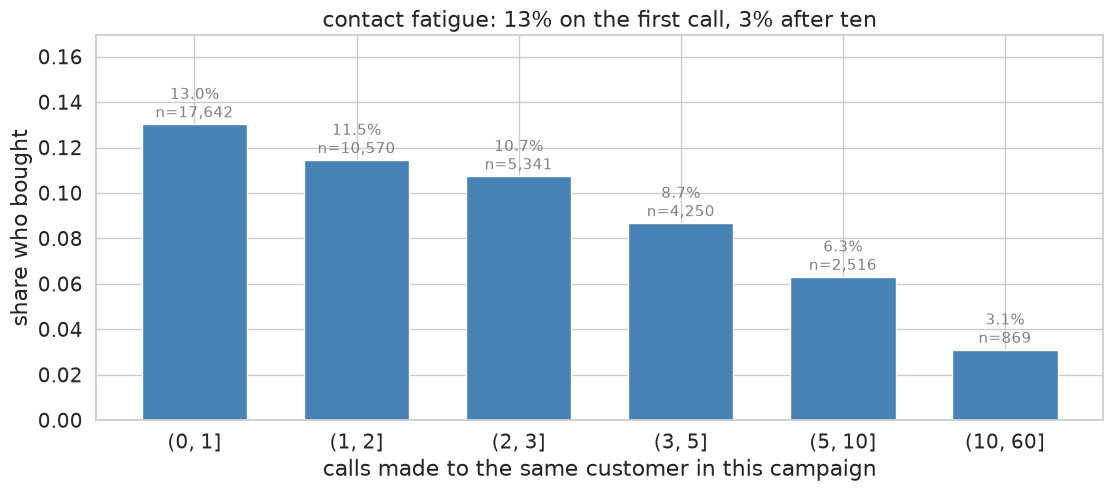

In [32]:
#plot it...every extra call to the same person works less well, with no exceptions
df = campaign_tab
sns.set(font_scale=1.3, font='DejaVu Sans', style='whitegrid')
fig, ax = plt.subplots(1, 1, figsize=(13, 5))
xp = range(len(df))
yp = df.sell_rate
p = ax.bar(xp, yp, color='steelblue', width=0.65)
for jdx in range(len(df)):
    p = ax.text(jdx, df.sell_rate.iloc[jdx] + 0.003,
                str(round(df.sell_rate.iloc[jdx]*100, 1)) + '%\nn=' + format(df.N_customers.iloc[jdx], ','),
                ha='center', fontsize=11, color='grey')
p = ax.set_xticks(list(xp))
p = ax.set_xticklabels([str(i) for i in df.index])
p = ax.set_ylim(0, df.sell_rate.max()*1.3)
p = ax.set_title('contact fatigue: 13% on the first call, 3% after ten')
p = ax.set_xlabel('calls made to the same customer in this campaign')
p = ax.set_ylabel('share who bought')

In [33]:
#bin the prevailing interest rate i4/euribor_3m*  and compute sell rate per bin. 
#euribor_3m* is bimodal: 27k customers were called when rates were above 4%, 13k when below 2%.
df = clean
euribor_bins = [0, 1, 2, 3, 4, 5.1]
euribor_tab = pd.DataFrame({'bin': pd.cut(df['euribor_3m*'], euribor_bins), 'y': y}).groupby(
    'bin', observed=True).agg(N_customers=('y', 'size'), sell_rate=('y', 'mean'))
euribor_tab.round(3)

,N_customers,sell_rate
bin,,
"(0.0, 1.0]",3908,0.457
"(1.0, 2.0]",9590,0.158
"(3.0, 4.0]",14,0.071
"(4.0, 5.1]",27676,0.048


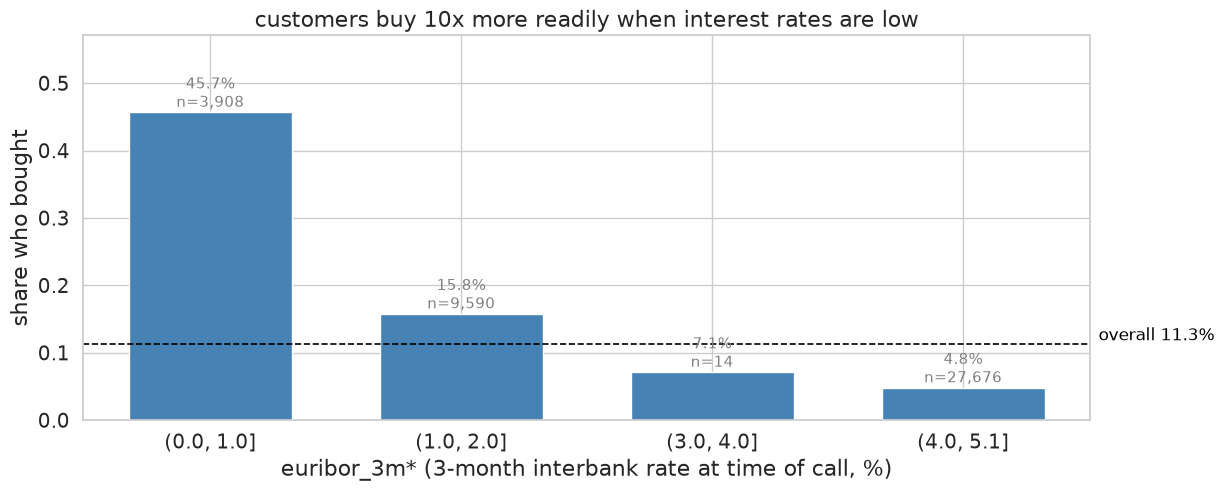

In [34]:
#plot it...the sell rate is ~10x higher in a low-rate economy than a high-rate one.
#this is the biggest single effect in the data, bigger than anything about the customer,
#and it is a warning for notebook 2: a random train/test split puts every rate
#environment on both sides of the split, so a model gets rewarded for learning the
#economy rather than the customer. notebook 3 measures how much that inflates the score.
df = euribor_tab
sns.set(font_scale=1.3, font='DejaVu Sans', style='whitegrid')
fig, ax = plt.subplots(1, 1, figsize=(13, 5))
xp = range(len(df))
yp = df.sell_rate
p = ax.bar(xp, yp, color='steelblue', width=0.65)
p = ax.axhline(y.mean(), color='black', linestyle='--', linewidth=1.2)
p = ax.text(len(df) - 0.5, y.mean(), '  overall ' + str(round(y.mean()*100, 1)) + '%',
            fontsize=12, color='black', va='bottom')
for jdx in range(len(df)):
    p = ax.text(jdx, df.sell_rate.iloc[jdx] + 0.008,
                str(round(df.sell_rate.iloc[jdx]*100, 1)) + '%\nn=' + format(df.N_customers.iloc[jdx], ','),
                ha='center', fontsize=11, color='grey')
p = ax.set_xticks(list(xp))
p = ax.set_xticklabels([str(i) for i in df.index])
p = ax.set_ylim(0, df.sell_rate.max()*1.25)
p = ax.set_title('customers buy 10x more readily when interest rates are low')
p = ax.set_xlabel('euribor_3m* (3-month interbank rate at time of call, %)')
p = ax.set_ylabel('share who bought')

In [35]:
#a trap worth flagging: month looks like powerful seasonality, an 8x swing from may to
#march, but the high-selling months are the ones falling in low-rate periods. holding the
#economy fixed, month goes nearly flat inside the biggest state (4.3-6.1% against 5.3%
#overall), so this is mostly the i4/euribor effect wearing a calendar. we keep month as a
#feature rather than dropping it, and notebook 3 settles it per economic state.
df = clean
month_tab = pd.DataFrame({'month': df.month, 'y': y, 'euribor': df['euribor_3m*']}).groupby(
    'month', observed=True).agg(N_customers=('y', 'size'), sell_rate=('y', 'mean'),
                                mean_euribor=('euribor', 'mean')).sort_values('sell_rate')
print('corr(sell_rate, mean_euribor) across months = ',
      round(month_tab.sell_rate.corr(month_tab.mean_euribor), 3))
print()
biggest = df['n_employed*'].value_counts().index[0]
sub = pd.DataFrame({'month': df.month, 'y': y})[df['n_employed*'] == biggest]
print('inside the biggest economic state (', biggest, ', N = ', format(len(sub), ','),
      ', overall ', round(sub.y.mean(), 3), '):', sep='')
print(sub.groupby('month').y.agg(['size', 'mean']).round(3).to_string())
print()
month_tab.round(3)

corr(sell_rate, mean_euribor) across months =  -0.892

inside the biggest economic state (5228.1, N = 16,234, overall 0.053):
       size   mean
month             
aug    5175  0.052
jul    6685  0.061
jun    4374  0.043



,N_customers,sell_rate,mean_euribor
month,,,
may,13769,0.064,3.294
jul,7174,0.090,4.686
nov,4101,0.101,3.723
jun,5318,0.105,4.257
aug,6178,0.106,4.301
apr,2632,0.205,1.361
oct,718,0.439,1.200
sep,570,0.449,0.835
dec,182,0.489,0.865


## 4. assemble the features, split, and save

In [36]:
#assemble the final feature list
x_cols = [
    #who the customer is
    'age', 'employment', 'marriage_status', 'school',
    'has_housing_loan*', 'has_personal_loan*', 'credit_in_default*',
    #how the campaign reached them
    'contact_channel*', 'month', 'dow',
    'contacts_this_campaign*', 'days_since_prior_contact*', 'prior_contact_count*',
    'prior_campaign_outcome*',
    #the two features derived above
    'never_contacted_before', 'is_repeat_contact',
    #economic conditions at the time of the call
    'emp_variation_rate*', 'consumer_price_index*', 'consumer_confidence_index*',
    'euribor_3m*', 'n_employed*',
    #the two random columns, kept deliberately as a noise floor for notebook 3
    'unknown_n3', 'unknown_n5',
]
y_col = 'target'
df = clean[x_cols].copy()
df[y_col] = y
xy = df
print('N_features    = ', len(x_cols))
print('xy.shape      = ', xy.shape)
print('N_categorical = ', xy[x_cols].select_dtypes('object').shape[1])
print('N_numeric     = ', xy[x_cols].select_dtypes('number').shape[1])
assert xy[y_col].notna().all()
xy.sample(5, random_state=rn_seed)

N_features    =  23
xy.shape      =  (41188, 24)
N_categorical =  10
N_numeric     =  13


,age,employment,marriage_status,school,has_housing_loan*,has_personal_loan*,credit_in_default*,contact_channel*,month,dow,contacts_this_campaign*,days_since_prior_contact*,prior_contact_count*,prior_campaign_outcome*,never_contacted_before,is_repeat_contact,emp_variation_rate*,consumer_price_index*,consumer_confidence_index*,euribor_3m*,n_employed*,unknown_n3,unknown_n5,target
16295,56,assistant,married,4 - average amount,no,no,no,old,jun,fri,2,-1.0,0,-1,1,1,1.4,94.465,-41.8,4.959,5228.1,730,-1.482944,0
10416,57,laborer,married,3 - a bit more,yes,no,no,new,may,tue,1,-1.0,0,-1,1,0,-1.8,92.893,-46.2,1.344,5099.1,860,0.336592,0
2888,56,hobbyist,married,3 - a bit more,yes,no,no,new,apr,wed,12,-1.0,0,-1,1,1,-1.8,93.075,-47.1,1.415,5099.1,630,1.246612,0
29163,26,laborer,single,3 - a bit more,yes,no,no,old,may,fri,1,-1.0,0,-1,1,0,1.1,93.994,-36.4,4.864,5191.0,640,0.808844,0
18945,56,leisure,married,4 - average amount,no,no,no,new,jun,tue,1,3.0,1,yes,0,0,-1.7,94.055,-39.8,0.761,4991.6,720,-0.430925,1


In [37]:
#stratified (equal split of buyers & nonbuyers) train/test split
from sklearn.model_selection import train_test_split
df = xy
xy_train, xy_test = train_test_split(df, test_size=test_size, stratify=df[y_col],
                                     random_state=rn_seed)
print('xy_train.shape = ', xy_train.shape, '  sell rate = ', round(xy_train[y_col].mean(), 4))
print('xy_test.shape  = ', xy_test.shape, '  sell rate = ', round(xy_test[y_col].mean(), 4))
assert len(xy_train) + len(xy_test) == len(xy)
assert len(set(xy_train.index) & set(xy_test.index)) == 0, 'train and test overlap'
assert abs(xy_train[y_col].mean() - xy_test[y_col].mean()) < 0.001

xy_train.shape =  (30891, 24)   sell rate =  0.1127
xy_test.shape  =  (10297, 24)   sell rate =  0.1127


In [38]:
#save, then read straight back to confirm nothing was lost in the round trip
xy_train.to_parquet('train.parquet')
xy_test.to_parquet('test.parquet')
train_check = pd.read_parquet('train.parquet')
test_check = pd.read_parquet('test.parquet')
print('train.parquet = ', train_check.shape, '  sell rate = ', round(train_check[y_col].mean(), 4))
print('test.parquet  = ', test_check.shape, '  sell rate = ', round(test_check[y_col].mean(), 4))
assert train_check.shape == xy_train.shape and test_check.shape == xy_test.shape
assert (train_check.dtypes == xy_train.dtypes).all(), 'dtypes changed on the round trip'
assert train_check[y_col].sum() == xy_train[y_col].sum()
print('both files read back identically...notebook 2 starts from here')
train_check.head()

train.parquet =  (30891, 24)   sell rate =  0.1127
test.parquet  =  (10297, 24)   sell rate =  0.1127
both files read back identically...notebook 2 starts from here


,age,employment,marriage_status,school,has_housing_loan*,has_personal_loan*,credit_in_default*,contact_channel*,month,dow,contacts_this_campaign*,days_since_prior_contact*,prior_contact_count*,prior_campaign_outcome*,never_contacted_before,is_repeat_contact,emp_variation_rate*,consumer_price_index*,consumer_confidence_index*,euribor_3m*,n_employed*,unknown_n3,unknown_n5,target
27851,36,assistant,married,5 - a decent amount,yes,yes,no,new,may,fri,1,-1.0,0,-1,1,0,-1.8,92.893,-46.2,1.259,5099.1,710,-1.606045,0
10560,33,assistant,married,5 - a lot,no,yes,no,new,sep,wed,1,-1.0,2,no,1,0,-1.1,94.199,-37.5,0.879,4963.6,660,-0.067963,1
32752,59,laborer,married,3 - a bit more,no,no,no,new,apr,thu,2,-1.0,1,no,1,1,-1.8,93.075,-47.1,1.410,5099.1,780,-1.070524,0
15442,54,assistant,married,1 - almost none,yes,no,-1,new,nov,tue,4,-1.0,0,-1,1,1,-0.1,93.200,-42.0,4.153,5195.8,990,-1.414095,0
25557,58,management,married,5 - a lot,yes,no,no,new,may,thu,2,-1.0,0,-1,1,1,-1.8,93.876,-40.0,0.692,5008.7,860,0.468118,1


## what we found

| finding | what it means for the project |
|---|---|
| `c10` is a verbatim copy of the answer | dropped |
| `n3` and `n5` are random numbers | kept as floor for feature importance chart |
| two adjacent education levels are both numbered "5" | left as is |
| missing values are written 4 ways, and `999` is not one of them | each needs its own handling |
| the same 990 customers are missing both loan fields | a systematic data-collection gap that is fixable at the source |
| only 11.3% of customers buy | accuracy is a meaningless measure here |
| prior success, contact channel, age and call count segment the customers the most | will monitor this at model validation time |
| month looks strongly seasonal but is mostly the economy in disguise | kept, but not to be read as "call in march" |
| sell rate is 10x higher when interest rates are low | training data is unevenly spread across rate environments, which can bias the model, and will be monitored at training time |


In [39]:
#done
print('execution time (min) = ', round((tm.time() - clock_start)/60.0, 3))

execution time (min) =  0.027
